# Google Colab runner: process every failed and missing record

This copy contains all seven model configurations from the comparison. It processes every clip whose prediction is failed or absent from its model cache. Successful records are skipped. There are no batch ranges.

Before running:

1. In Colab choose **Runtime > Change runtime type > GPU**.
2. Put `NVTV_PublicData1` in `MyDrive`, including `automatic_ground_truth_v4/ground_truth_metadata_615.json`, the `clips` folder, and all seven latest `qwen_vl_comparison/predictions_*.json` cache files.
3. Run the notebook from the top. Google Drive is mounted automatically.
4. Run the notebook from the top. No range or batch configuration is required.

The prediction JSON is checkpointed to Google Drive every five attempted clips. If Colab disconnects, reconnect and run the notebook again; successful retries are skipped automatically.

Based on the latest screenshot, this run has 537 records to attempt: 2B Instruct = 2, 2B Thinking = 135, 4B Instruct = 3, and 4B Thinking = 397. The two InternVL models and Qwen 8B Instruct are complete and should be skipped.

The 537 attempts comprise 54 existing failed records and 483 missing records. Both categories are included in this notebook.

After all batches, download the updated prediction JSON files from Google Drive and copy them back to the same `qwen_vl_comparison` folder on Kelvin2.


# Original comparison-method notes (reference)

These are the original notebook's methodological notes. For this runnable
copy, follow the **Google Colab runner** instructions in the cell above;
the Colab configuration later in the notebook overrides the old paths and
runs the configured unfinished records while skipping completed model caches.

- **Environment:** run this from the `qwen-gpu` conda environment
  (`conda activate qwen-gpu`) on a GPU-allocated node, with `jupyter lab`
  started there and reached via an SSH tunnel from your local machine.
  Section 1 installs the Python packages this notebook needs -- it does
  **not** reinstall `torch`, so your existing CUDA-matched build is left
  alone.
- **Data:** Section 2's `Config.project_root` points at
  `~/sharedscratch/nvtv_qwen` by default -- the `automatic_ground_truth_v4`
  folder (metadata + clips) should already be there if you followed the
  Kelvin2 setup steps. Edit `project_root` if you put it somewhere else.
- **Full 615-clip corpus, no held-out split:** Section 4 reads `ground_truth_metadata_615.json` (all 615 clips from the full corpus, not the smaller 76-clip calibration/evaluation ground truth). This source has no calibration/evaluation split recorded, so every model is scored against the whole corpus -- there is no train/held-out separation for this run. Note that clearly wherever these results are reported.
- **8B runs int4-quantized here**, via `bitsandbytes` (CUDA-only, unlike
  the Mac variant's `optimum-quanto`, which was needed there only because
  bitsandbytes doesn't support MPS). Testing showed 8.77B params in bf16
  (~17.5GB) leaves too little headroom on a 20GB MIG slice -- it was
  consistently using nearly the entire slice and OOMing on any small
  amount of competing GPU usage, even with the reduced frame budget below.

This notebook is a standalone companion to the main dissertation pipeline
notebook (`NVTV_MSc_Dissertation_FOCUSED_5_METADATA_ONLY.ipynb`). It does
**not** re-run that pipeline. Instead it:

1. Loads the automatic ground-truth metadata that pipeline already produced
   for all **76 clips** (`ground_truth_metadata.json`, both the 14-clip
   calibration split and the 62-clip evaluation split).
2. Runs **five Qwen3-VL models** zero-shot over the same clips to generate
   their own metadata for the same fields, from the same video frames, then
   frees each model from memory before loading the next.
3. Scores every model's output against the automatic ground truth, deliberately
   **not F1**: a single ROUGE-L **recall** score for the three free-text
   fields (`on_screen_text`, `keywords`, `transcript`), and a single
   `accuracy` score for the two categorical/numeric fields
   (`visual_tags`, `people_count`).
4. Builds a **comparison table**: one row per model, one column per
   metadata field, so all five models can be read off side by side.

## Which models, and why not "all of them"

The Hugging Face `Qwen/qwen3-vl` collection lists about 18 repos, but most
are quantized re-packagings of the same underlying checkpoints, or sizes
too large for a single MIG `2g.20gb` slice. This notebook runs:

- `Qwen/Qwen3-VL-2B-Instruct`
- `Qwen/Qwen3-VL-2B-Thinking`
- `Qwen/Qwen3-VL-4B-Instruct`
- `Qwen/Qwen3-VL-4B-Thinking`
- `Qwen/Qwen3-VL-8B-Instruct` -- int4-quantized via bitsandbytes (see above)

**Excluded entirely, with reasons:**

- **32B-Instruct / 32B-Thinking (and their `-FP8` variants).** Needs
  roughly 64GB in bf16, or ~16-20GB even 4-bit quantized -- more than a
  single `2g.20gb` MIG slice provides. `k2-gpu-a100mig` also offers
  `3g.40gb` slices; a 32B model quantized might fit one of those, but
  that's a different SLURM GPU request than what this notebook assumes.
- **Every `-FP8` checkpoint.** Native FP8 tensor core support depends on
  the specific A100 partition/driver configuration and isn't something to
  assume works well here; bf16 is the safe, well-supported default.
- **Every `-GGUF` checkpoint** (32B and the 8B-GGUF build also visible in
  the collection). GGUF files are built for `llama.cpp`-style runtimes,
  not the Hugging Face `transformers` pipeline this notebook uses for
  everything else -- supporting them would mean a second, unrelated
  inference stack. (The plain, non-GGUF `Qwen3-VL-8B-Instruct` used above
  is a different, separately-published checkpoint from that GGUF build.)

If you request a `3g.40gb` MIG slice (or the full A100) instead, `MODEL_CONFIGS`
in Section 2 is a plain list -- just add a row.

**Scope note -- `transcript` is included as a deliberate stress test, not a
fair transcription task.** None of these models take audio input, so any
`transcript_guess` they produce is necessarily speculative -- inferred from
visual cues alone (lip movement, body language, on-screen text), not real
transcription. It's scored anyway, alongside `on_screen_text`, `visual_tags`,
`keywords` (here: keywords the model infers from what it can see in the
frames, not from speech), and `people_count`, specifically to quantify how
much speech content is *not* recoverable from vision alone -- low scores
here are an expected, disclosed finding, not evidence the models performed
badly at a task they could reasonably have succeeded at. This is called out
again in the Limitations section.

**Ground truth used:** the *automatic* consensus metadata
(`ground_truth_metadata.json`), not the human-verified reference file --
i.e. each model is compared against the fixed multi-model pipeline's own
output, not against human ground truth.


## 1. Environment setup

Make sure this notebook's kernel is the `qwen-gpu` conda environment
(JupyterLab's kernel picker, top right) before running this. This does
**not** reinstall `torch` -- your existing CUDA-matched build
(`2.7.1+cu118`) is left alone; it only installs/upgrades the other
packages this notebook needs. Qwen3-VL support in `transformers` is
recent, so this also checks whether the installed version actually
recognises the `qwen3_vl` architecture and upgrades to the GitHub `main`
branch if not, which is normal for a model family this new.


In [1]:
import subprocess
import sys
import os
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=False)
COLAB_HF_HOME = Path("/content/huggingface-cache")
COLAB_HF_HOME.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(COLAB_HF_HOME)
os.environ["HF_HUB_CACHE"] = str(COLAB_HF_HOME / "hub")


def run_setup(command: list[str]) -> None:
    print("\nRunning:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.returncode != 0:
        print(result.stderr[-4000:])
        raise RuntimeError(f"Setup command failed: {' '.join(command)}")


# torch is deliberately NOT in this list -- keep Colab's CUDA-matched
# build. Frames are sampled and handed
# to the processor directly as PIL images (Section 6), so qwen-vl-utils'
# video-loading helpers aren't needed. rouge-score is Google's reference
# ROUGE implementation. bitsandbytes is CUDA-only 4-bit quantization --
# unlike the Mac variant (which needed optimum-quanto because bitsandbytes
# doesn't support MPS), this is real CUDA, so bitsandbytes is the natural
# choice for the one model that needs it (see MODEL_CONFIGS below).
PACKAGES = [
    "transformers>=4.57.0,<6",
    "accelerate>=0.30.0",
    "bitsandbytes",
    "opencv-python-headless",
    "rouge-score==0.1.2",
    "pillow",
    "tqdm",
    "huggingface-hub",
    "matplotlib",
    "ipywidgets",
]

run_setup([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-cache-dir",
    "--quiet",
    *PACKAGES,
])

print("Setup complete.")

Mounted at /content/drive

Running: /usr/bin/python3 -m pip install --no-cache-dir --quiet transformers>=4.57.0,<6 accelerate>=0.30.0 bitsandbytes opencv-python-headless rouge-score==0.1.2 pillow tqdm huggingface-hub matplotlib ipywidgets
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.6 MB/s eta 0:00:00
Setup complete.


In [2]:
import importlib

import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING

if "qwen3_vl" not in CONFIG_MAPPING:
    print(
        f"transformers {transformers.__version__} does not list qwen3_vl -- "
        "installing the latest development version from GitHub..."
    )
    run_setup([
        sys.executable, "-m", "pip", "install", "--no-cache-dir", "--upgrade", "--quiet",
        "git+https://github.com/huggingface/transformers.git",
    ])
    importlib.reload(transformers)
    from transformers.models.auto.configuration_auto import CONFIG_MAPPING as _RELOADED_MAPPING
    if "qwen3_vl" not in _RELOADED_MAPPING:
        raise RuntimeError(
            "qwen3_vl is still not recognised after upgrading transformers. "
            "Restart this notebook's kernel and re-run from the top -- a "
            "fresh Python process is sometimes needed to pick up an "
            "in-place transformers upgrade."
        )

print(f"transformers {transformers.__version__} supports Qwen3-VL.")


transformers 5.16.1 supports Qwen3-VL.


## 2. Configuration

`project_root` below points at `MyDrive/NVTV_PublicData1` -- edit it if
your folder has a different name in Google Drive. Everything else matches the
main pipeline notebook's `Config` layout so the rest of this notebook's
paths line up. `MODEL_CONFIGS` is the list explained in the intro above --
edit it if your hardware or the available checkpoints change.


In [3]:
from __future__ import annotations

import gc
import json
import os
import random
import re
import time
import traceback
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

SEED = 40490925
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
else:
    MODEL_DTYPE = torch.float32
print("Device:", DEVICE, "| dtype:", MODEL_DTYPE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "WARNING: no CUDA GPU detected -- in Colab choose Runtime > "
        "Change runtime type > GPU, then reconnect and rerun."
    )
    raise RuntimeError("This notebook requires a Colab GPU runtime.")


@dataclass
class Config:
    # Google Drive copy of the same NVTV_PublicData1 folder used on Kelvin2.
    project_root: Path = Path("/content/drive/MyDrive/NVTV_PublicData1")
    output_subdir: str = "automatic_ground_truth_v4"

    @property
    def artifact_dir(self) -> Path:
        return self.project_root / self.output_subdir

    @property
    def clip_dir(self) -> Path:
        return self.artifact_dir / "clips"

    @property
    def ground_truth_file(self) -> Path:
        # Full 615-clip corpus (no calibration/evaluation split recorded --
        # see Section 4), not the smaller 76-clip split ground truth.
        return self.artifact_dir / "ground_truth_metadata_focused.json"

    @property
    def qwen_output_dir(self) -> Path:
        return self.artifact_dir / "qwen_vl_comparison"



CFG = Config()
CFG.qwen_output_dir.mkdir(parents=True, exist_ok=True)

# All models visible in the comparison screenshot. Completed models are
# detected from their caches and skipped before any weights are loaded.
MODEL_CONFIGS = [
    {"name": "InternVL3-2B", "repo_id": "OpenGVLab/InternVL3-2B-hf", "trust_remote_code": True},
    {"name": "InternVL3-8B", "repo_id": "OpenGVLab/InternVL3-8B-hf", "trust_remote_code": True, "quantize_int4": True},
    {"name": "Qwen3-VL-2B-Instruct", "repo_id": "Qwen/Qwen3-VL-2B-Instruct"},
    {"name": "Qwen3-VL-2B-Thinking", "repo_id": "Qwen/Qwen3-VL-2B-Thinking"},
    {"name": "Qwen3-VL-4B-Instruct", "repo_id": "Qwen/Qwen3-VL-4B-Instruct"},
    {"name": "Qwen3-VL-4B-Thinking", "repo_id": "Qwen/Qwen3-VL-4B-Thinking"},
    {"name": "Qwen3-VL-8B-Instruct", "repo_id": "Qwen/Qwen3-VL-8B-Instruct", "quantize_int4": True},
]

# Identifies which model(s) a given run of this notebook covers, so the
# summary files in Sections 9/10/13 never collide when several copies of
# this notebook -- each with MODEL_CONFIGS trimmed to one model -- write
# into the same shared CFG.qwen_output_dir (e.g. run as separate Kelvin2
# jobs, one per model, possibly overlapping in time). Per-model
# prediction caches (Section 8) are already namespaced by model name and
# do not need this.
RUN_TAG = "_".join(
    re.sub(r"[^A-Za-z0-9_.-]+", "_", m["name"]) for m in MODEL_CONFIGS
)


# Keep these inference settings equal to the Kelvin2 run for comparability.
QWEN_MAX_FRAMES = 4          # frames sampled per clip, uniformly spaced
QWEN_CHECKPOINT_EVERY = 5    # clips between checkpoint saves
MAX_CLIPS_PER_MODEL: Optional[int] = None

# No batching: every currently failed or missing record is attempted.
# Only successful records are excluded by the inference loop.

# The same controlled vocabulary the main pipeline's CLIP tagger and Gemini
# stage use, so visual_tags are drawn from the same label space and a
# multi-label accuracy comparison against the ground truth is meaningful.
VISUAL_LABELS = (
    "news studio", "interview", "press conference", "public meeting",
    "panel discussion", "person speaking", "crowd of people", "protest",
    "indoor scene", "outdoor scene", "city street", "building exterior",
    "office", "stage", "podium", "fire engine", "emergency services",
    "police", "hospital", "school", "graphic or title card",
    "text on screen", "logo", "presentation slide", "landscape",
    "rural countryside", "vehicle", "road", "sign or banner",
    "audience", "reporter", "politician", "firefighter", "uniform",
)
TAG_TOP_K = 5

print("Ground truth file:", CFG.ground_truth_file)
print("Clip directory:", CFG.clip_dir)
print("This notebook's outputs:", CFG.qwen_output_dir)
print("Models to benchmark:", [m["name"] for m in MODEL_CONFIGS])


Device: cuda | dtype: torch.bfloat16
GPU: NVIDIA A100-SXM4-40GB
Ground truth file: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/ground_truth_metadata_focused.json
Clip directory: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/clips
This notebook's outputs: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison
Models to benchmark: ['InternVL3-2B', 'InternVL3-8B', 'Qwen3-VL-2B-Instruct', 'Qwen3-VL-2B-Thinking', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-4B-Thinking', 'Qwen3-VL-8B-Instruct']


In [4]:
print("Models retained:", len(MODEL_CONFIGS))

for model_config in MODEL_CONFIGS:
    print(model_config["name"])

Models retained: 7
InternVL3-2B
InternVL3-8B
Qwen3-VL-2B-Instruct
Qwen3-VL-2B-Thinking
Qwen3-VL-4B-Instruct
Qwen3-VL-4B-Thinking
Qwen3-VL-8B-Instruct


## 3. Text-normalisation and scoring helpers

Normalisation helpers (`normalize_space`, `normalize_key`, ...) are copied
verbatim from the main pipeline notebook. Scoring is **ROUGE-1 / ROUGE-2 /
ROUGE-L recall** (all three variants, no F1) for free-text fields, and a
single **accuracy** score for categorical/numeric fields.


In [5]:
from rouge_score import rouge_scorer


def normalize_space(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip()


def normalize_key(value: Any) -> str:
    return re.sub(r"[^a-z0-9]+", " ", normalize_space(value).lower()).strip()


def unique_strings(values: Iterable[str]) -> list[str]:
    output, seen = [], set()
    for value in values:
        clean = normalize_space(value)
        key = normalize_key(clean)
        if clean and key and key not in seen:
            seen.add(key)
            output.append(clean)
    return output


def plausible_ocr_text(value: Any) -> bool:
    text = normalize_space(value)
    if not text or len(text) > 160:
        return False
    non_space = [c for c in text if not c.isspace()]
    alphanumeric = sum(c.isalnum() for c in non_space)
    if not non_space or alphanumeric / len(non_space) < 0.50:
        return False
    key = normalize_key(text)
    return len(key) >= 2 or key.isdigit()


NUMBER_WORDS = {
    "zero": 0, "none": 0, "nobody": 0, "one": 1, "single": 1,
    "two": 2, "couple": 2, "three": 3, "few": 3, "four": 4,
    "five": 5, "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
}


def parse_people_count(value: Any) -> Optional[int]:
    text = normalize_key(value)
    match = re.search(r"\b\d+\b", text)
    if match:
        return int(match.group())
    for token in text.split():
        if token in NUMBER_WORDS:
            return NUMBER_WORDS[token]
    return None


# A single "rouge" score per field, deliberately not a rouge1/rouge2/rougeL
# breakdown. ROUGE-L (longest common subsequence) is used as that single
# number: it rewards matching word order, not just bag-of-words overlap,
# and stays informative on short text where ROUGE-2 (bigram overlap) tends
# to go to zero.
ROUGE_SCORER = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def rouge_recall(reference: Iterable[str], prediction: Iterable[str]) -> float:
    """ROUGE-L **recall** (not F-measure) between two text lists.

    Lists are joined into one text blob per side before scoring, since
    on_screen_text / keywords / transcript are unordered or single-passage
    text rather than needing a multi-variant breakdown. Both-empty is a
    perfect match; one-sided empty is a total miss.
    """
    reference_text = normalize_space(" ".join(reference or []))
    prediction_text = normalize_space(" ".join(prediction or []))
    if not reference_text and not prediction_text:
        return 1.0
    if not reference_text or not prediction_text:
        return 0.0
    return float(ROUGE_SCORER.score(reference_text, prediction_text)["rougeL"].recall)


def multilabel_accuracy(
    reference: Iterable[str], prediction: Iterable[str], vocabulary: Iterable[str],
) -> float:
    """Hamming accuracy: fraction of vocabulary labels correctly predicted
    present-or-absent (both true positives and true negatives count)."""
    reference_set = {normalize_key(v) for v in (reference or [])}
    prediction_set = {normalize_key(v) for v in (prediction or [])}
    vocabulary_keys = [normalize_key(v) for v in vocabulary]
    correct = sum((v in reference_set) == (v in prediction_set) for v in vocabulary_keys)
    return correct / len(vocabulary_keys)


def bounded(value: float) -> float:
    return float(min(1.0, max(0.0, value)))


def write_json_atomic(payload: Any, path: Path) -> None:
    temp_path = path.with_name(path.stem + ".partial.json")
    with open(temp_path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2)
    os.replace(temp_path, path)


def write_csv_atomic(frame: pd.DataFrame, path: Path) -> None:
    temp_path = path.with_name(path.stem + ".partial.csv")
    frame.to_csv(temp_path, index=False)
    os.replace(temp_path, path)


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

print("Helpers ready.")


Helpers ready.


## 4. Load ground truth and build the clip list (full 615-clip corpus)

This ground truth file covers the full 615-clip corpus and carries no calibration/evaluation split (that split only exists in the smaller 76-clip ground truth produced by the current pipeline run). Every clip with a matching video file on disk is scored -- there is no held-out subset here, which is a real methodological difference from the split-aware 76-clip runs and should be reported as such.


In [6]:
if not CFG.ground_truth_file.exists():
    raise FileNotFoundError(
        f"Ground truth file not found: {CFG.ground_truth_file}\n"
        "Check Config.project_root in Section 2 -- it should point at the "
        "folder containing automatic_ground_truth_v4/ in Google Drive "
        "(default: /content/drive/MyDrive/NVTV_PublicData1)."
    )

with open(CFG.ground_truth_file, encoding="utf-8") as handle:
    GROUND_TRUTH = json.load(handle)

ok_clips = [clip for clip in GROUND_TRUTH.get("clips", []) if clip.get("status") == "ok"]
print(f"Ground truth clips total: {len(GROUND_TRUTH.get('clips', []))}")
print(f"Usable ('ok' status) clips: {len(ok_clips)}")

CLIP_ROWS = []
MISSING_VIDEO_FILES = []
for clip in ok_clips:
    clip_path = CFG.clip_dir / f"{clip['clip_id']}.mp4"
    if not clip_path.exists():
        MISSING_VIDEO_FILES.append(clip_path)
        continue
    CLIP_ROWS.append({
        "clip_id": clip["clip_id"],
        "source_id": clip.get("source_id", ""),
        "source_video": clip.get("source_video", ""),
        "split": clip.get("split", ""),
        "clip_path": clip_path,
        "ground_truth_metadata": clip["ground_truth_metadata"],
    })

if MISSING_VIDEO_FILES:
    print("First missing video files:")
    for missing_path in MISSING_VIDEO_FILES[:10]:
        print("  ", missing_path)
    raise FileNotFoundError(
        f"{len(MISSING_VIDEO_FILES)} required MP4 clips are absent from Google Drive. "
        "Upload them before running inference."
    )

CLIP_MANIFEST = pd.DataFrame(CLIP_ROWS)
print(f"Clips with a video file on disk: {len(CLIP_MANIFEST)}")

# No calibration/evaluation split recorded in this ground truth source
# (see Section 4 intro) -- every available clip is used as-is, rather
# than filtering to a held-out subset.
if "split" in CLIP_MANIFEST.columns and CLIP_MANIFEST["split"].astype(bool).any():
    print("Split info is present after all -- NOT auto-filtering to "
          "evaluation-only; add that filter back explicitly if you want it.")

CLIP_MANIFEST[["clip_id", "split", "source_video"]].head()


Ground truth clips total: 626
Usable ('ok' status) clips: 626
Clips with a video file on disk: 626


,clip_id,split,source_video
0,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,10. Jacobin Launch 230316.mp4
1,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,10. Jacobin Launch 230316.mp4
2,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,10. Jacobin Launch 230316.mp4
3,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,10. Jacobin Launch 230316.mp4
4,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,10. Jacobin Launch 230316.mp4


## 5. Model loading / unloading helpers

Nothing is loaded yet -- Section 8 calls `load_qwen_model()` once per model
in `MODEL_CONFIGS`, runs it over all clips, then calls `unload_qwen_model()`
before moving to the next one, so only one model ever sits in GPU memory
at a time (keeps this within the MIG slice's 20GB budget).

Every Qwen3-VL checkpoint here is fully public on Hugging Face -- no login
or token is required. A `401`/`RepositoryNotFoundError` means a **stale or
invalid Hugging Face token** is being sent with the request and rejected by
the server (which HF's API reports as "repo not found" rather than "bad
token"). `load_qwen_model` clears any cached token first (`get_token()`
checks both env vars and a token file left over from an earlier
`huggingface-cli login` / `notebook_login()`), then downloads via
`snapshot_download(..., token=False)` -- a lower-level function with more
reliable anonymous-access handling -- and loads from the resulting local
folder, which needs no further network/auth calls at all.

`load_qwen_model` also tries three different loader classes in order
(`AutoModelForMultimodalLM` -- what Qwen's own model card currently
recommends for Qwen3-VL -- then `AutoModelForImageTextToText`, then a
`trust_remote_code=True` fallback), since a model family this new can move
between auto-class registrations across transformers versions.

`load_qwen_model(repo_id, quantize_int4=...)` applies bitsandbytes int4
quantization when the flag is set (only `Qwen3-VL-8B-Instruct` sets it in
`MODEL_CONFIGS`) -- see the intro cell for why 8B specifically needs this.


In [7]:
from huggingface_hub import get_token, logout, snapshot_download
from transformers import AutoModel, AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

try:
    from transformers import AutoModelForMultimodalLM
except ImportError:
    AutoModelForMultimodalLM = None


def clear_cached_hf_token() -> None:
    if get_token() is not None:
        print("Clearing a cached Hugging Face token so downloads are anonymous...")
        logout()
        os.environ.pop("HF_TOKEN", None)
        os.environ.pop("HUGGING_FACE_HUB_TOKEN", None)


def load_qwen_model(
    repo_id: str, quantize_int4: bool = False, trust_remote_code: bool = False,
) -> tuple[Any, Any, int]:
    clear_cached_hf_token()
    local_path = snapshot_download(
        repo_id=repo_id,
        token=False,
        cache_dir=os.environ.get("HF_HUB_CACHE", "/content/huggingface-cache/hub"),
    )
    processor = AutoProcessor.from_pretrained(local_path, trust_remote_code=trust_remote_code)

    load_kwargs: dict[str, Any] = {
        "torch_dtype": MODEL_DTYPE,
        # {"": 0} pins the whole model onto the single GPU explicitly,
        # rather than "auto"'s heuristic placement. This notebook only
        # ever has one model in memory at a time (Section 8 fully unloads
        # each model before loading the next), so there's never a reason
        # to let "auto" split a model across devices -- and "auto" was
        # observed repeatedly deciding to CPU-offload part of even a
        # 4.44B bf16 model (~8.9GB, trivially fits a 20GB slice) via the
        # "Some parameters are on the meta device" warning, and outright
        # erroring for the int4-quantized 8B model (bitsandbytes refuses
        # to let auto-placement CPU-offload a quantized module without an
        # explicit opt-in, but "auto" tried to anyway).
        "device_map": {"": 0} if DEVICE == "cuda" else None,
    }
    if DEVICE == "cuda":
        load_kwargs["attn_implementation"] = "sdpa"
    if quantize_int4 and DEVICE == "cuda":
        # bitsandbytes int4 -- CUDA-only, so only applied when DEVICE is
        # "cuda" (always true here in practice; MODEL_CONFIGS only sets
        # quantize_int4 for 8B, and this notebook is meant to be run on a
        # GPU node in the first place). nf4 + double quant is bnb's
        # standard recommended combination for inference quality.
        load_kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=MODEL_DTYPE,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        load_kwargs.pop("torch_dtype", None)  # dtype comes from bnb_4bit_compute_dtype instead

    model = None
    last_error: Optional[Exception] = None
    for loader, extra_kwargs in (
        (AutoModelForMultimodalLM, {"trust_remote_code": trust_remote_code}),
        (AutoModelForImageTextToText, {"trust_remote_code": trust_remote_code}),
        (AutoModel, {"trust_remote_code": True}),
    ):
        if loader is None:
            continue
        try:
            model = loader.from_pretrained(local_path, **load_kwargs, **extra_kwargs)
            break
        except Exception as exc:
            last_error = exc
            print(f"{loader.__name__} failed ({exc}); trying the next loader...")
    if model is None:
        raise RuntimeError(f"No loader could load {repo_id}") from last_error

    model = model.eval()
    if DEVICE != "cuda":
        model = model.to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    return processor, model, n_params


def unload_qwen_model() -> None:
    # Deliberately takes no arguments: `del` on a parameter only clears the
    # local name inside this function, not the caller's own variable, so a
    # model passed in here would still be referenced (and resident in GPU
    # memory) by the caller's variable after this function returns. The
    # caller must `del` its own qwen_processor/qwen_model names *before*
    # calling this -- that's what actually drops the refcount to zero so
    # gc.collect() and empty_cache() have something to free.
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


print("Model loading helpers ready.")


Model loading helpers ready.


## 6. Frame sampling

This notebook samples frames **uniformly** (evenly spaced across the clip
duration) rather than reusing the main pipeline's scene-aware sampler. This
is a deliberate simplification so the evaluation protocol is simple,
independent and easy to describe/reproduce on its own -- it does not depend
on PySceneDetect or the main notebook's frame cache. It is noted again in
the Limitations section.


In [8]:
def sample_frames_uniform(clip_path: Path, max_frames: int) -> list[Image.Image]:
    cap = cv2.VideoCapture(str(clip_path))
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV could not open {clip_path}")
    try:
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        duration = frame_count / fps if fps > 0 else 0.0
        if duration <= 0:
            raise ValueError(f"Invalid duration for {clip_path}")

        fractions = np.linspace(0.05, 0.95, max_frames)
        images = []
        for fraction in fractions:
            at_sec = float(duration * fraction)
            cap.set(cv2.CAP_PROP_POS_MSEC, at_sec * 1000.0)
            ok, bgr = cap.read()
            if not ok:
                continue
            images.append(Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))
        if not images:
            raise RuntimeError(f"Could not decode any frames from {clip_path}")
        return images
    finally:
        cap.release()

# Smoke test on the first clip.
_test_frames = sample_frames_uniform(CLIP_MANIFEST.iloc[0]["clip_path"], QWEN_MAX_FRAMES)
print(f"Sampled {len(_test_frames)} frames from {CLIP_MANIFEST.iloc[0]['clip_id']}, size={_test_frames[0].size}")


Sampled 4 frames from 10_Jacobin_Launch_230316_13c6f149__030000ms__clip0000, size=(1920, 1080)


## 7. Prompt and JSON parsing

The `-Thinking` models emit a reasoning trace before their final answer, so
the parser here scans for **every** balanced top-level `{...}` block in the
output and keeps the **last** one that parses as valid JSON (the final
answer), rather than the first (which could just be an example the model's
own reasoning mentions).


In [9]:
QWEN_PROMPT_VERSION = "nvtv-qwen3vl-family-v3"

QWEN_PROMPT = f"""
You are an independent visual metadata annotator for an academic video-archive
study. The supplied images are chronological frames from one silent video
clip -- you do not have access to the audio, so do not guess at names,
locations or events that are not visibly supported (the one exception is
field 5 below, which explicitly asks for a speculative guess).

Use visible evidence only. Do not identify named people. Do not complete
cropped, blurred or partly hidden text.

If you reason before answering, be decisive and brief: give your single
best estimate for ambiguous cases (such as a crowd size that varies across
frames) without repeatedly reconsidering it. Always end your response with
the JSON object below and nothing after it.

Return a single JSON object with exactly these five keys:

1. "on_screen_text": array of exact strings copied from clearly legible
   on-screen text (captions, titles, signage). Empty array if none is
   clearly legible.
2. "visual_tags": array of at most {TAG_TOP_K} strings, chosen ONLY from
   this exact vocabulary (copy the strings exactly):
   {json.dumps(list(VISUAL_LABELS), ensure_ascii=False)}
3. "keywords": array of at most 8 short topical keywords or keyphrases
   describing what is visually happening in the clip (based only on what
   you can see -- you have no audio).
4. "people_count_numeric": your best single estimate of the typical number
   of clearly visible people across the frames, as an integer. Use -1 if a
   reliable count is impossible (e.g. a dense crowd or nobody visible).
5. "transcript_guess": a short, best-effort guess at what might be being
   said in this clip, based ONLY on visual cues (lip movement, body
   language, on-screen text, setting, who appears to be speaking) -- you
   have no audio, so this is necessarily speculative, not real
   transcription. Keep it brief (one short sentence or phrase). Return an
   empty string "" if the frames give you no reasonable basis to guess at
   all -- an honest empty guess is preferred over an invented one.
""".strip()


def extract_last_json_object(text: str) -> Optional[dict]:
    """Return the LAST balanced {...} block in `text` that parses as JSON.

    Robust to -Thinking models that print a reasoning trace (which may
    itself mention example JSON) before their real final answer.
    """
    matches = []
    depth = 0
    start = None
    for index, character in enumerate(text):
        if character == "{":
            if depth == 0:
                start = index
            depth += 1
        elif character == "}":
            if depth > 0:
                depth -= 1
                if depth == 0 and start is not None:
                    candidate = text[start:index + 1]
                    try:
                        matches.append(json.loads(candidate))
                    except json.JSONDecodeError:
                        pass
                    start = None
    return matches[-1] if matches else None


ALLOWED_TAGS = {normalize_key(label): label for label in VISUAL_LABELS}


def normalize_qwen_output(raw: dict) -> dict:
    on_screen_text = [
        item for item in unique_strings(raw.get("on_screen_text", []) or [])
        if plausible_ocr_text(item)
    ][:20]

    selected_tags = []
    for candidate in unique_strings(raw.get("visual_tags", []) or []):
        canonical = ALLOWED_TAGS.get(normalize_key(candidate))
        if canonical and canonical not in selected_tags:
            selected_tags.append(canonical)
    selected_tags = selected_tags[:TAG_TOP_K]

    keywords = unique_strings(raw.get("keywords", []) or [])[:8]

    people_raw = raw.get("people_count_numeric", -1)
    try:
        people = int(people_raw)
    except (TypeError, ValueError):
        people = -1
    people_count_numeric = None if people < 0 or people > 500 else people

    transcript_guess = str(raw.get("transcript_guess", "") or "").strip()

    return {
        "on_screen_text": on_screen_text,
        "visual_tags": selected_tags,
        "keywords": keywords,
        "people_count_numeric": people_count_numeric,
        "transcript_guess": transcript_guess,
    }

print("Prompt and parser ready.")


Prompt and parser ready.


In [10]:
def predictions_file_for(model_name: str) -> Path:
    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        model_name,
    )

    return (
        CFG.qwen_output_dir
        / f"predictions_{safe_name}.json"
    )


def load_predictions_for(
    model_name: str,
) -> dict[str, dict]:
    path = predictions_file_for(model_name)

    if not path.exists():
        print(f"No cache found for {model_name}: {path}")
        return {}

    with open(path, encoding="utf-8") as handle:
        payload = json.load(handle)

    if (
        payload.get("prompt_version")
        != QWEN_PROMPT_VERSION
    ):
        print(
            f"Prompt version mismatch for {model_name}; "
            "ignoring its cache."
        )
        return {}

    records = {
        record["clip_id"]: record
        for record in payload.get("records", [])
        if record.get("clip_id")
    }

    print(
        f"Loaded cache: {path.name} "
        f"({len(records)} records)"
    )

    return records


def save_predictions_for(
    model_name: str,
    records: dict[str, dict],
) -> None:
    ordered = [
        records[clip_id]
        for clip_id in CLIP_MANIFEST["clip_id"]
        if clip_id in records
    ]

    payload = {
        "schema_version": "1.0",
        "model": model_name,
        "prompt_version": QWEN_PROMPT_VERSION,
        "max_frames": QWEN_MAX_FRAMES,
        "updated_utc": utc_now(),
        "records": ordered,
    }

    write_json_atomic(
        payload,
        predictions_file_for(model_name),
    )


@torch.inference_mode()
def run_model_on_clip(
    processor: Any,
    model: Any,
    clip_path: Path,
    max_new_tokens: int,
) -> str:
    frames = sample_frames_uniform(
        clip_path,
        QWEN_MAX_FRAMES,
    )

    messages = [
        {
            "role": "user",
            "content": [
                *[
                    {
                        "type": "image",
                        "image": frame,
                    }
                    for frame in frames
                ],
                {
                    "type": "text",
                    "text": QWEN_PROMPT,
                },
            ],
        }
    ]

    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[chat_text],
        images=frames,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.15,
        no_repeat_ngram_size=8,
    )

    trimmed_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(
            inputs.input_ids,
            generated_ids,
        )
    ]

    return processor.batch_decode(
        trimmed_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


_FORCE_CONCLUDE_TEXT = (
    "\n\nI will stop analyzing now and give my "
    'final answer as JSON.\n\n{'
)


@torch.inference_mode()
def force_json_continuation(
    processor: Any,
    model: Any,
    clip_path: Path,
    raw_text: str,
    max_new_tokens: int = 400,
) -> str:
    frames = sample_frames_uniform(
        clip_path,
        QWEN_MAX_FRAMES,
    )

    messages = [
        {
            "role": "user",
            "content": [
                *[
                    {
                        "type": "image",
                        "image": frame,
                    }
                    for frame in frames
                ],
                {
                    "type": "text",
                    "text": QWEN_PROMPT,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": (
                        raw_text
                        + _FORCE_CONCLUDE_TEXT
                    ),
                }
            ],
        },
    ]

    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        continue_final_message=True,
    )

    inputs = processor(
        text=[chat_text],
        images=frames,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.15,
        no_repeat_ngram_size=8,
    )

    trimmed_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(
            inputs.input_ids,
            generated_ids,
        )
    ]

    continuation = processor.batch_decode(
        trimmed_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    return (
        raw_text
        + _FORCE_CONCLUDE_TEXT
        + continuation
    )


print("Prediction-cache and inference helpers ready.")

Prediction-cache and inference helpers ready.


## 8. Run every model over all clips (checkpointed per model, resumable)

Loads one model, runs it over every clip, checkpoints to its own
predictions file, fully frees it from GPU memory, then moves to the next
model in `MODEL_CONFIGS`. If a model fails to load or crashes, it's recorded
in `MODEL_LOAD_FAILURES`/skipped and the loop continues with the rest rather
than aborting the whole run. `-Thinking` models get a larger
`max_new_tokens` budget to leave room for their reasoning trace before the
final JSON answer.

**`-Thinking` fallback:** if a `-Thinking` model still doesn't produce
parseable JSON within its budget (observed: it can spend the entire budget
deliberating on one ambiguous detail -- e.g. a crowd size or an unclear
character in on-screen text -- without ever concluding), one additional
short generation call (`force_json_continuation`, up to 400 more tokens)
continues the model's own response with an explicit "stop reasoning, answer
now" instruction, seeded with an opening `{` to bias it toward finishing
the JSON. This only runs for clips that already failed the first pass, and
only for `-Thinking` models -- see Limitations for the methodological
caveat this introduces.

**This can take a while** (five models x up to 62 evaluation clips each, even
on a 20GB MIG slice). Set `MAX_CLIPS_PER_MODEL = 3` in Section 2 first to
smoke-test that the whole loop works end to end -- and to get a real sense of
per-clip timing -- before committing to a full run.


In [11]:
ALL_QWEN_RECORDS: dict[str, dict[str, dict]] = {}
MODEL_LOAD_FAILURES: dict[str, str] = {}

for model_cfg in MODEL_CONFIGS:
    model_name = model_cfg["name"]
    repo_id = model_cfg["repo_id"]

    print(f"\n{'=' * 70}")
    print(f"{model_name} ({repo_id})")
    print("=" * 70)

    records = load_predictions_for(model_name)
    clips_to_run = CLIP_MANIFEST

    if not records:
        message = (
            f"No valid existing cache loaded for {model_name}. Upload "
            f"{predictions_file_for(model_name).name} before running failed clips."
        )
        print("SKIPPING:", message)
        MODEL_LOAD_FAILURES[model_name] = message
        ALL_QWEN_RECORDS[model_name] = records
        continue

    pending = [
        row
        for row in clips_to_run.itertuples(index=False)
        if records.get(row.clip_id, {}).get("status") != "ok"
    ]

    cached_ok = sum(
        records.get(str(row.clip_id), {}).get("status") == "ok"
        for row in clips_to_run.itertuples(index=False)
    )

    current_missing_total = sum(
        row.clip_id not in records for row in clips_to_run.itertuples(index=False)
    )
    current_failed_total = sum(
        row.clip_id in records and records[row.clip_id].get("status") != "ok"
        for row in clips_to_run.itertuples(index=False)
    )
    print(f"Successful cached results: {cached_ok}")
    print(f"Existing failed records to retry: {current_failed_total}")
    print(f"Missing records to create: {current_missing_total}")
    print(f"Total records to process now (no range): {len(pending)}")

    ALL_QWEN_RECORDS[model_name] = records

    if not pending:
        print(f"{model_name}: complete; skipping model loading.")
        continue

    try:
        qwen_processor, qwen_model, n_params = load_qwen_model(
            repo_id,
            quantize_int4=model_cfg.get("quantize_int4", False),
            trust_remote_code=model_cfg.get("trust_remote_code", False),
        )

        quant_note = (
            " (int4)"
            if model_cfg.get("quantize_int4", False)
            else ""
        )

        print(
            f"Loaded {model_name}: "
            f"{n_params / 1e9:.2f}B parameters "
            f"on {DEVICE}{quant_note}."
        )

    except Exception as exc:
        message = f"{type(exc).__name__}: {exc}"
        print(f"COULD NOT LOAD {model_name}: {message}")
        MODEL_LOAD_FAILURES[model_name] = message
        continue

    max_new_tokens = 1400 if "Thinking" in model_name else 700

    since_checkpoint = 0
    try:
        for row in tqdm(pending, desc=f"{model_name} inference"):
            started = time.perf_counter()
            raw_text = None
            try:
                raw_text = run_model_on_clip(
                    qwen_processor, qwen_model, row.clip_path, max_new_tokens
                )
                parsed = extract_last_json_object(raw_text)
                if parsed is None and model_name.startswith("Qwen3-VL"):
                    print(
                        f"{row.clip_id}: normal output was not valid JSON; "
                        "trying forced JSON continuation."
                    )
                    forced_text = force_json_continuation(
                        qwen_processor,
                        qwen_model,
                        row.clip_path,
                        raw_text,
                        max_new_tokens=700,
                    )
                    forced_parsed = extract_last_json_object(forced_text)
                    if forced_parsed is not None:
                        raw_text, parsed = forced_text, forced_parsed
                if parsed is None:
                    raise ValueError(
                        f"Could not parse JSON from model output: {raw_text[:200]!r}"
                    )
                metadata = normalize_qwen_output(parsed)
                records[row.clip_id] = {
                    "clip_id": row.clip_id,
                    "status": "ok",
                    "error": None,
                    "processed_utc": utc_now(),
                    "processing_seconds": round(time.perf_counter() - started, 3),
                    "raw_response": raw_text,
                    "metadata": metadata,
                }
            except Exception as exc:
                records[row.clip_id] = {
                    "clip_id": row.clip_id,
                    "status": "error",
                    "error": {
                        "type": type(exc).__name__,
                        "message": str(exc),
                        "traceback": traceback.format_exc(limit=6),
                    },
                    "processed_utc": utc_now(),
                    "processing_seconds": round(time.perf_counter() - started, 3),
                    "raw_response": raw_text,
                }

            since_checkpoint += 1
            if since_checkpoint >= QWEN_CHECKPOINT_EVERY:
                save_predictions_for(model_name, records)
                since_checkpoint = 0
    finally:
        # Save even when the user interrupts the cell between normal checkpoints.
        save_predictions_for(model_name, records)
        ALL_QWEN_RECORDS[model_name] = records
        del qwen_processor, qwen_model
        unload_qwen_model()
        print(f"Saved {predictions_file_for(model_name)}")
        print(f"Unloaded {model_name}; GPU memory freed.")

    n_ok = sum(r.get("status") == "ok" for r in records.values())
    n_error = sum(r.get("status") == "error" for r in records.values())
    print(f"{model_name}: {n_ok} ok, {n_error} failed.")

print("\nModels that failed to load:", MODEL_LOAD_FAILURES or "none")



InternVL3-2B (OpenGVLab/InternVL3-2B-hf)
Loaded cache: predictions_InternVL3-2B.json (615 records)
Successful cached results: 615
Existing failed records to retry: 0
Missing records to create: 11
Total records to process now (no range): 11


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/781 [00:00<?, ?it/s]

...

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loaded Qwen3-VL-8B-Instruct: 5.01B parameters on cuda (int4).


Qwen3-VL-8B-Instruct inference:   0%|          | 0/11 [00:00<?, ?it/s]

Saved /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/predictions_Qwen3-VL-8B-Instruct.json
Unloaded Qwen3-VL-8B-Instruct; GPU memory freed.
Qwen3-VL-8B-Instruct: 626 ok, 0 failed.

Models that failed to load: none


## 9. Score every model's output against the automatic ground truth

Produces one row per (model, clip, field): `on_screen_text`, `keywords`
and `transcript` each produce one `rouge` row (ROUGE-L recall);
`visual_tags` and `people_count` each produce one `accuracy` row. This
long format is kept in `QWEN_ACCURACY_REPORT` so Section 10 can build
the comparison table.


In [15]:
SCORED_FIELDS = ("on_screen_text", "visual_tags", "keywords", "people_count", "transcript")


def ground_truth_value(clip_metadata: dict, field: str) -> Any:
    evidence = clip_metadata.get(field, {})
    return evidence.get("value") if isinstance(evidence, dict) else evidence


def ground_truth_agreement_tier(clip_metadata: dict, field: str) -> str:
    evidence = clip_metadata.get(field, {})
    if isinstance(evidence, dict):
        return evidence.get("agreement_tier", "not_scored")
    return "not_scored"


def score_clip_field(field: str, reference: Any, prediction: Any) -> dict[str, float]:
    """Returns {metric_name: value}; empty dict means "not scoreable", not zero."""
    if field in {"on_screen_text", "keywords"}:
        return {"rouge": rouge_recall(reference or [], prediction or [])}
    if field == "visual_tags":
        return {"accuracy": multilabel_accuracy(reference or [], prediction or [], VISUAL_LABELS)}
    if field == "people_count":
        expected = parse_people_count(reference)
        if expected is None:
            return {}
        return {"accuracy": float(prediction == expected)}
    if field == "transcript":
        # transcript is a single passage of text (unlike on_screen_text /
        # keywords, which are unordered lists of short strings), so it's
        # wrapped as a one-element list before reusing rouge_recall --
        # that reduces to scoring the two raw strings directly, since
        # " ".join([text]) == text. A model's genuinely-honest empty
        # string ("no reasonable guess") against a non-empty ground truth
        # transcript scores 0.0 here, same as any other miss -- this is
        # not treated as a special case, since the models never had audio
        # access and low/zero scores here are an expected, disclosed
        # finding, not a bug (see Limitations).
        reference_text = reference if isinstance(reference, str) else None
        return {"rouge": rouge_recall(
            [reference_text] if reference_text else [],
            [prediction] if prediction else [],
        )}
    raise ValueError(f"Unsupported field: {field}")


rows = []
for model_cfg in MODEL_CONFIGS:
    model_name = model_cfg["name"]
    records_for_model = ALL_QWEN_RECORDS.get(model_name, {})
    for row in CLIP_MANIFEST.itertuples(index=False):
        prediction_record = records_for_model.get(row.clip_id, {})
        if prediction_record.get("status") != "ok":
            continue
        qwen_metadata = prediction_record["metadata"]

        predictions = {
            "on_screen_text": qwen_metadata["on_screen_text"],
            "visual_tags": qwen_metadata["visual_tags"],
            "keywords": qwen_metadata["keywords"],
            "people_count": qwen_metadata["people_count_numeric"],
            "transcript": qwen_metadata["transcript_guess"],
        }
        for field in SCORED_FIELDS:
            reference = ground_truth_value(row.ground_truth_metadata, field)
            tier = ground_truth_agreement_tier(row.ground_truth_metadata, field)
            for metric_name, value in score_clip_field(field, reference, predictions[field]).items():
                rows.append({
                    "model": model_name,
                    "clip_id": row.clip_id,
                    "split": row.split,
                    "field": field,
                    "metric": metric_name,
                    "value": bounded(value),
                    "ground_truth_value": reference,
                    "qwen_value": predictions[field],
                    "ground_truth_agreement_tier": tier,
                })

QWEN_ACCURACY_REPORT = pd.DataFrame(rows)
QWEN_ACCURACY_REPORT_FILE = CFG.qwen_output_dir / f"qwen_vl_accuracy_report__{RUN_TAG}.csv"
write_csv_atomic(QWEN_ACCURACY_REPORT, QWEN_ACCURACY_REPORT_FILE)
print(f"Scored {len(QWEN_ACCURACY_REPORT)} (model, clip, field) rows.")
print("Saved to:", QWEN_ACCURACY_REPORT_FILE)

# One additional CSV per model -- the combined file above is the
# complete long-format record, but a separate file per model makes it
# easy to open, share or diff one model's results at a time.
PER_MODEL_ACCURACY_FILES: dict[str, Path] = {}
for model_name_ in QWEN_ACCURACY_REPORT["model"].unique():
    safe_name_ = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_name_)
    per_model_file_ = CFG.qwen_output_dir / f"qwen_vl_accuracy_report_{safe_name_}.csv"
    write_csv_atomic(
        QWEN_ACCURACY_REPORT[QWEN_ACCURACY_REPORT["model"] == model_name_],
        per_model_file_,
    )
    PER_MODEL_ACCURACY_FILES[model_name_] = per_model_file_
print(f"\nAlso wrote {len(PER_MODEL_ACCURACY_FILES)} per-model file(s):")
for model_name_, path_ in PER_MODEL_ACCURACY_FILES.items():
    print(f"  {model_name_}: {path_}")

QWEN_ACCURACY_REPORT.head(10)


Scored 21489 (model, clip, field) rows.
Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_accuracy_report__InternVL3-2B_InternVL3-8B_Qwen3-VL-2B-Instruct_Qwen3-VL-2B-Thinking_Qwen3-VL-4B-Instruct_Qwen3-VL-4B-Thinking_Qwen3-VL-8B-Instruct.csv

Also wrote 7 per-model file(s):
  InternVL3-2B: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_accuracy_report_InternVL3-2B.csv
  InternVL3-8B: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_accuracy_report_InternVL3-8B.csv
  Qwen3-VL-2B-Instruct: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_accuracy_report_Qwen3-VL-2B-Instruct.csv
  Qwen3-VL-2B-Thinking: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_accuracy_report_Qwen3-VL-2B-Thinking.csv
  Qwen3-VL-4B-Instruct: /content/drive/MyDrive/NVTV_PublicData1/automati

,model,clip_id,split,field,metric,value,ground_truth_value,qwen_value,ground_truth_agreement_tier
0,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,on_screen_text,rouge,0.000000,"[Jacobin, of the, American, on politics:]","[PROCLAMATION, ISSUE 21 SPRING 2019]",not_scored
1,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,visual_tags,accuracy,0.852941,"[interview, person speaking, reporter, text on...","[interview, stage, crowd of people, person spe...",not_scored
2,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,keywords,rouge,0.083333,"[ideas, publication, jackamon socialist, socia...","[political event, lecture, discussion, journal...",not_scored
3,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,people_count,accuracy,0.000000,10,7,not_scored
4,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,transcript,rouge,0.000000,Jackman is a socialist publication. We're rais...,,not_scored
5,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,on_screen_text,rouge,0.000000,[Ronan Burtenshaw],"[REP, THE WORKING CLASS]",not_scored
6,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,visual_tags,accuracy,0.823529,"[audience, person speaking, interview, reporter]","[interview, stage, crowd of people, presentati...",not_scored
7,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,keywords,rouge,0.000000,"[debating, southern perspective, create broad,...","[interview, stage, speaker, crowd of people]",not_scored
8,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,people_count,accuracy,0.000000,4,6,not_scored
9,InternVL3-2B,10_Jacobin_Launch_230316_13c6f149__030000ms__c...,,transcript,rouge,0.017857,and the things that they're debating and talki...,A person is giving an interview.,not_scored


## 10. Comparison table: accuracy and rouge, per model, per field (evaluation split)

The main deliverable: one row per model, one column per (metadata field,
metric) pair, scored on the 62-clip evaluation split only.
`on_screen_text`/`keywords`/`transcript` each get three columns -- ROUGE-1,
ROUGE-2 and ROUGE-L recall (all three are reported, since "ROUGE" alone
doesn't refer to one specific score); `visual_tags`/`people_count` each get
one accuracy column. A coverage table is shown alongside it since models
can fail to load, or fail JSON parsing on different clips -- a score from
fewer clips is less reliable, and this makes that visible rather than
hiding it. `transcript` scores are expected to be low across the board --
see the intro cell and Limitations for why that's a disclosed finding, not
a bug.


In [16]:
FIELD_METRIC = {
    "on_screen_text": "rouge",
    "keywords": "rouge",
    "visual_tags": "accuracy",
    "people_count": "accuracy",
    "transcript": "rouge",
}
FIELD_ORDER = ["on_screen_text", "keywords", "visual_tags", "people_count", "transcript"]
MODEL_ORDER = [m["name"] for m in MODEL_CONFIGS]

coverage_table = QWEN_ACCURACY_REPORT.pivot_table(
    index="model", columns="field", values="clip_id", aggfunc="nunique",
).reindex(index=MODEL_ORDER, columns=FIELD_ORDER).fillna(0).astype(int)
QWEN_COVERAGE_TABLE_FILE = CFG.qwen_output_dir / f"qwen_vl_coverage_table__{RUN_TAG}.csv"
write_csv_atomic(coverage_table.reset_index(), QWEN_COVERAGE_TABLE_FILE)
print(f"Clips scored per model x field (out of {len(CLIP_MANIFEST)} total):")
display(coverage_table)
print("Saved to:", QWEN_COVERAGE_TABLE_FILE)

comparison_table = QWEN_ACCURACY_REPORT.pivot_table(
    index="model", columns="field", values="value", aggfunc="mean",
).reindex(index=MODEL_ORDER, columns=FIELD_ORDER)
comparison_table.columns = [f"{field} ({FIELD_METRIC[field]})" for field in comparison_table.columns]
comparison_table = comparison_table.round(3)

QWEN_COMPARISON_TABLE_FILE = CFG.qwen_output_dir / f"qwen_vl_comparison_table__{RUN_TAG}.csv"
write_csv_atomic(comparison_table.reset_index(), QWEN_COMPARISON_TABLE_FILE)
print(f"\nMean score per model x field (n={len(CLIP_MANIFEST)} clips):")
display(comparison_table)
print("Saved to:", QWEN_COMPARISON_TABLE_FILE)

if MODEL_LOAD_FAILURES:
    print("\nModels excluded from the tables above because they failed to load:")
    for name, reason in MODEL_LOAD_FAILURES.items():
        print(f"  {name}: {reason}")


Clips scored per model x field (out of 626 total):


field,on_screen_text,keywords,visual_tags,people_count,transcript
model,,,,,
InternVL3-2B,626,626,626,568,626
InternVL3-8B,626,626,626,568,626
Qwen3-VL-2B-Instruct,625,625,625,567,625
Qwen3-VL-2B-Thinking,624,624,624,566,624
Qwen3-VL-4B-Instruct,626,626,626,568,626
Qwen3-VL-4B-Thinking,626,626,626,568,626
Qwen3-VL-8B-Instruct,626,626,626,568,626


Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_coverage_table__InternVL3-2B_InternVL3-8B_Qwen3-VL-2B-Instruct_Qwen3-VL-2B-Thinking_Qwen3-VL-4B-Instruct_Qwen3-VL-4B-Thinking_Qwen3-VL-8B-Instruct.csv

Mean score per model x field (n=626 clips):


,on_screen_text (rouge),keywords (rouge),visual_tags (accuracy),people_count (accuracy),transcript (rouge)
model,,,,,
InternVL3-2B,0.544,0.031,0.890,0.417,0.000
InternVL3-8B,0.416,0.027,0.883,0.366,0.013
Qwen3-VL-2B-Instruct,0.383,0.039,0.871,0.233,0.034
Qwen3-VL-2B-Thinking,0.384,0.028,0.874,0.323,0.018
Qwen3-VL-4B-Instruct,0.456,0.030,0.880,0.241,0.000
Qwen3-VL-4B-Thinking,0.389,0.040,0.873,0.315,0.019
Qwen3-VL-8B-Instruct,0.431,0.036,0.876,0.232,0.000


Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/qwen_vl_comparison_table__InternVL3-2B_InternVL3-8B_Qwen3-VL-2B-Instruct_Qwen3-VL-2B-Thinking_Qwen3-VL-4B-Instruct_Qwen3-VL-4B-Thinking_Qwen3-VL-8B-Instruct.csv


## 11. Does the pipeline's own agreement_score predict how close each model gets?

Each ground-truth field already carries an `agreement_tier`
(`not_scored` / `low_agreement` / `moderate_agreement` / `high_agreement`)
from the main pipeline's own cross-model corroboration. This produces one
chart per model, grouping its score by that tier: if fields the pipeline
itself is confident about are also the fields every independent model
agrees with most, that is a useful corroborating signal for the
dissertation's core premise -- and whether it holds consistently across
model sizes is itself worth reporting.


Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/InternVL3-2B_vs_agreement_tier.png


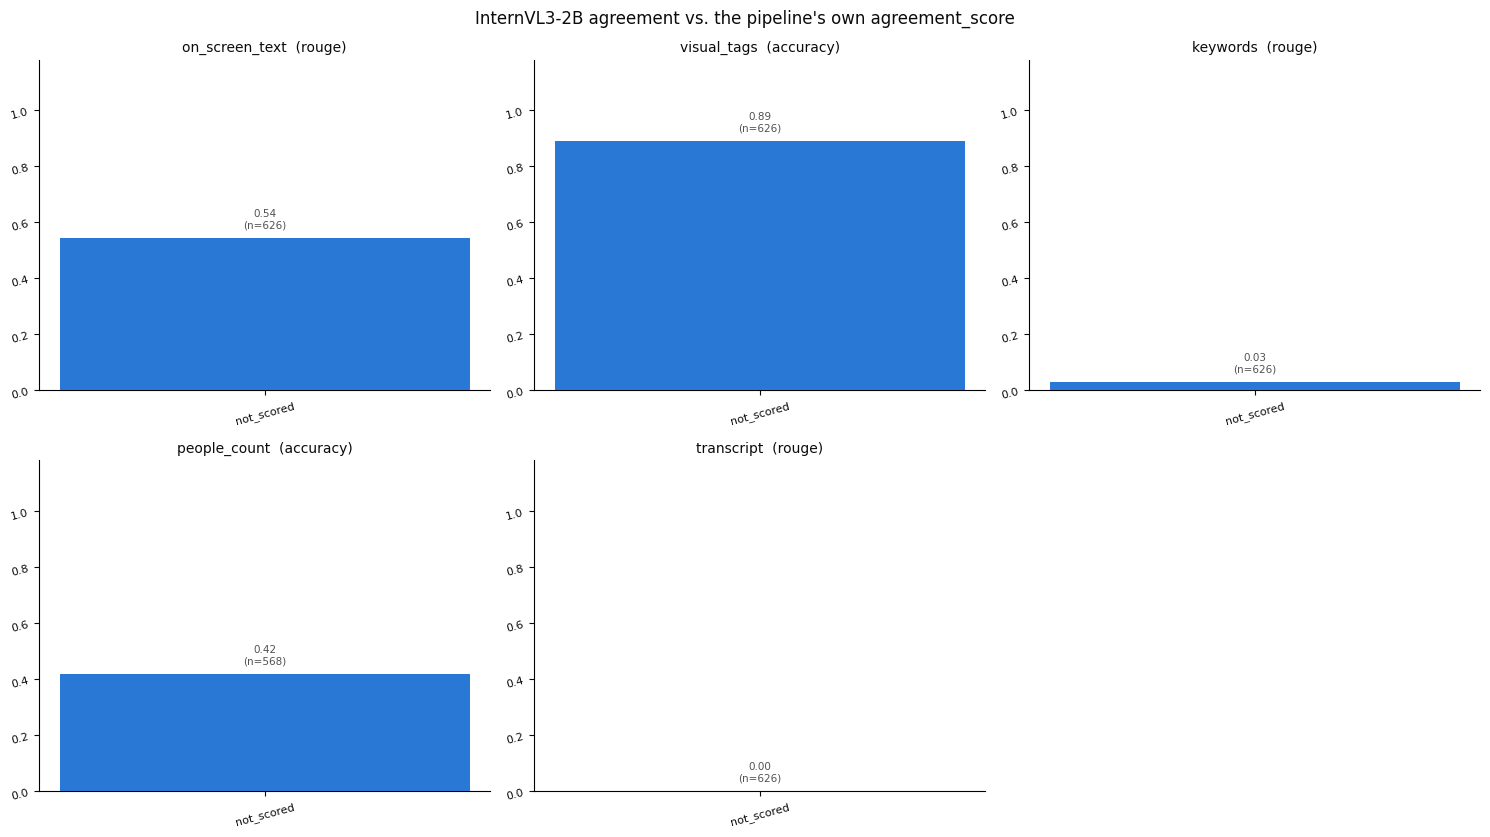

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/InternVL3-8B_vs_agreement_tier.png


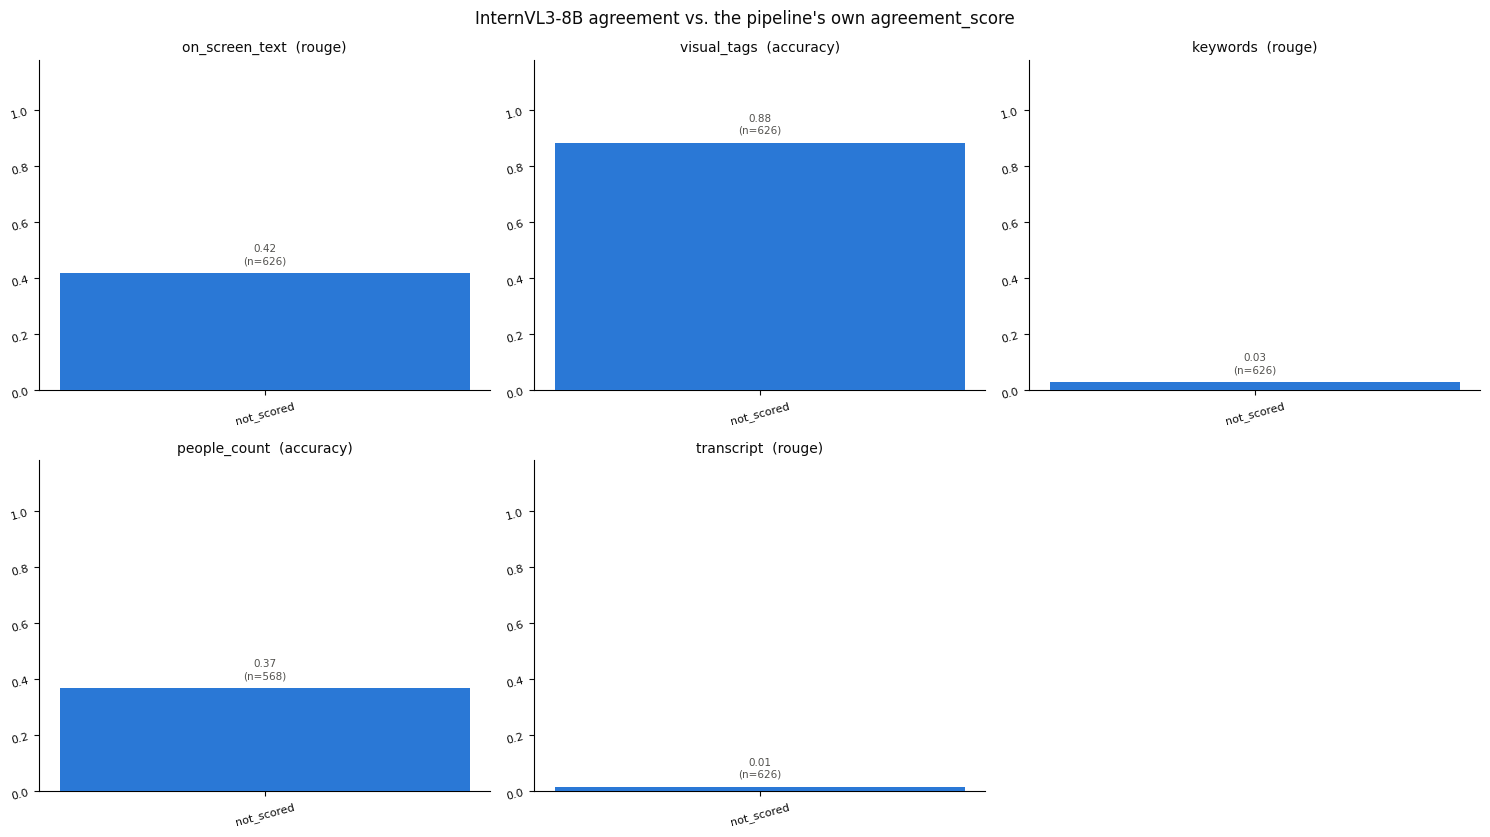

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/Qwen3-VL-2B-Instruct_vs_agreement_tier.png


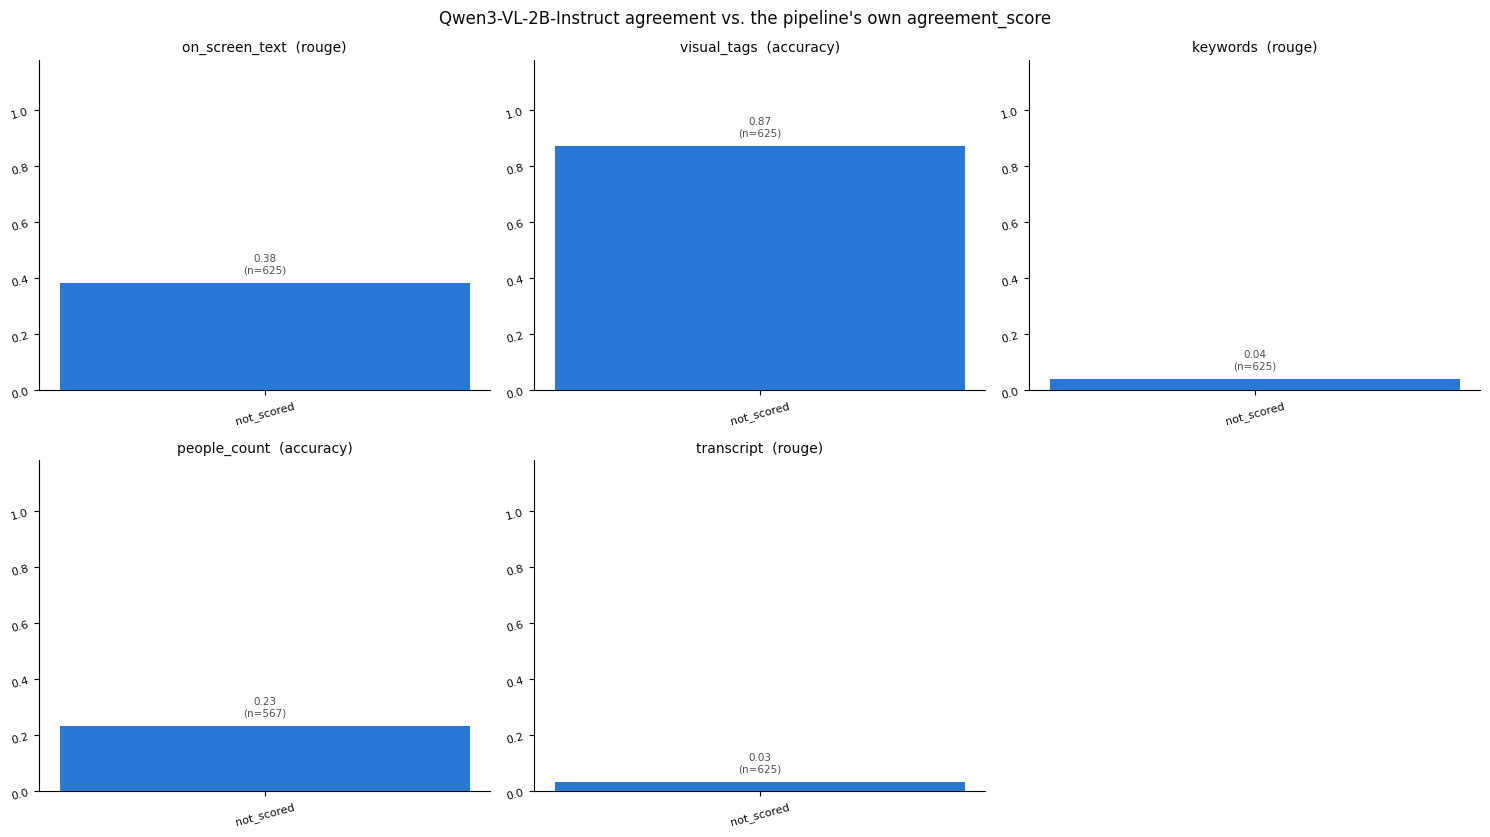

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/Qwen3-VL-2B-Thinking_vs_agreement_tier.png


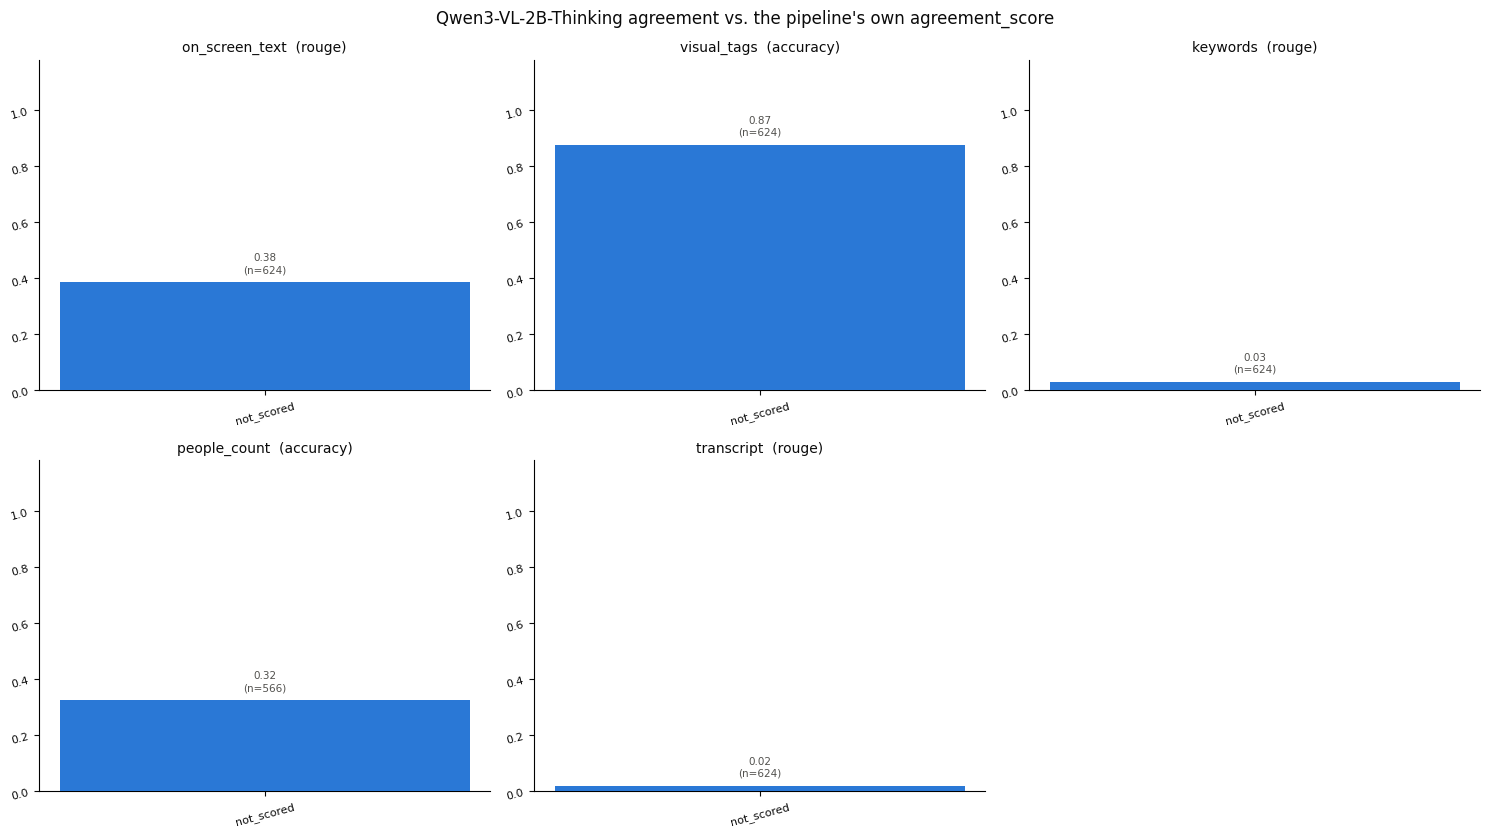

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/Qwen3-VL-4B-Instruct_vs_agreement_tier.png


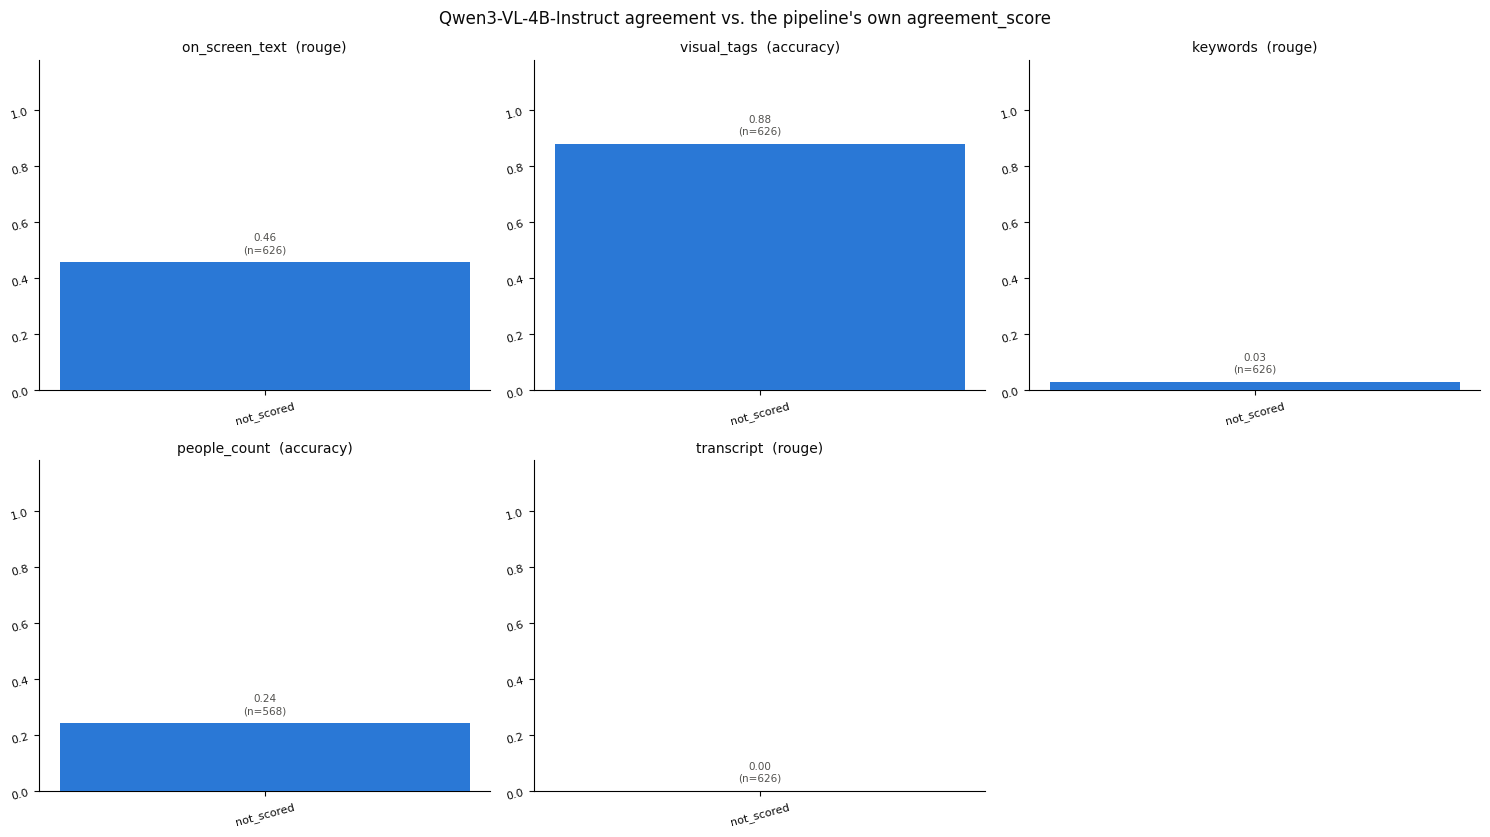

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/Qwen3-VL-4B-Thinking_vs_agreement_tier.png


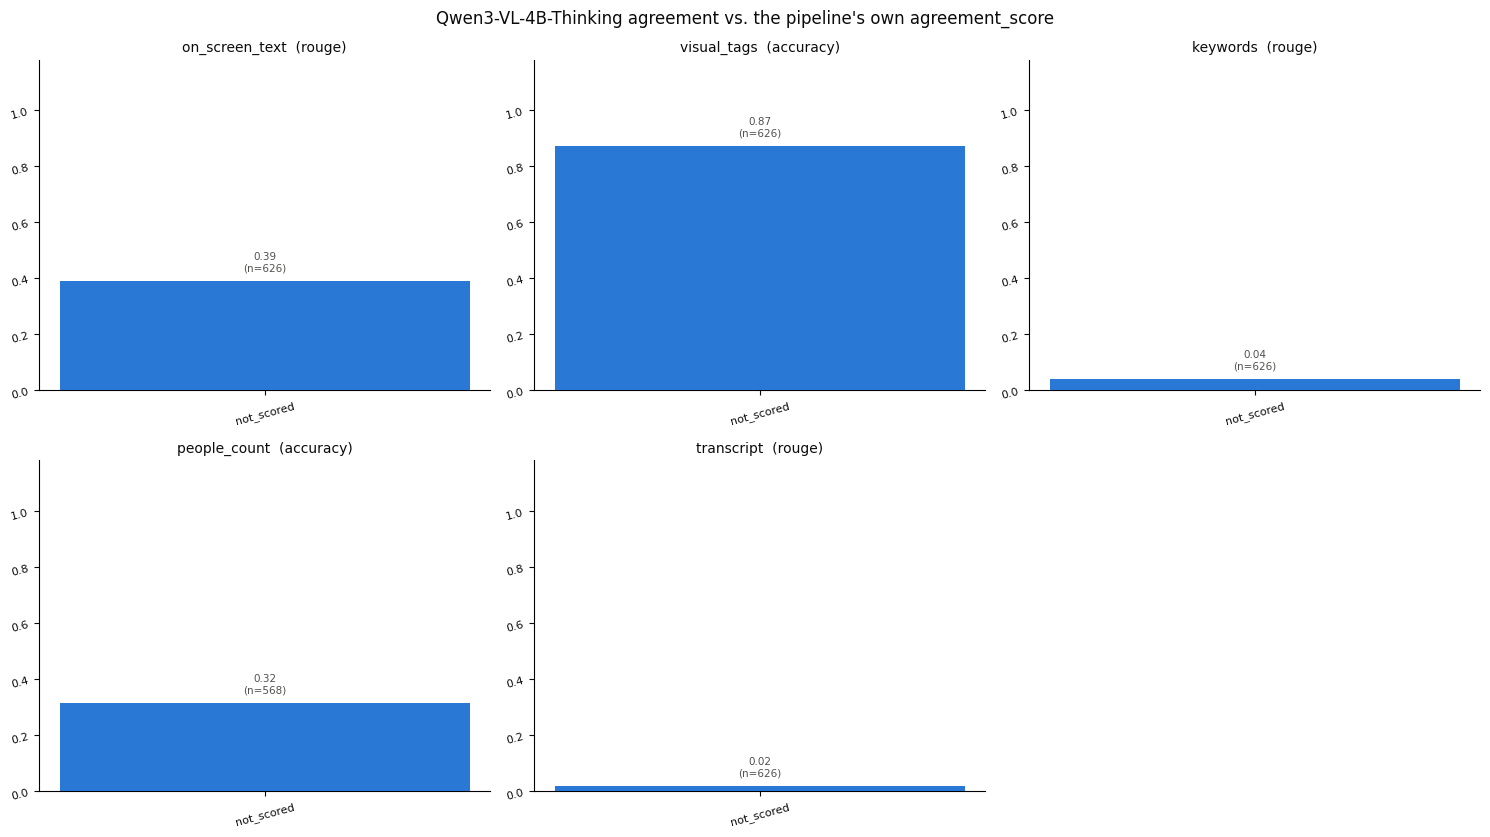

Saved to: /content/drive/MyDrive/NVTV_PublicData1/automatic_ground_truth_v4/qwen_vl_comparison/Qwen3-VL-8B-Instruct_vs_agreement_tier.png


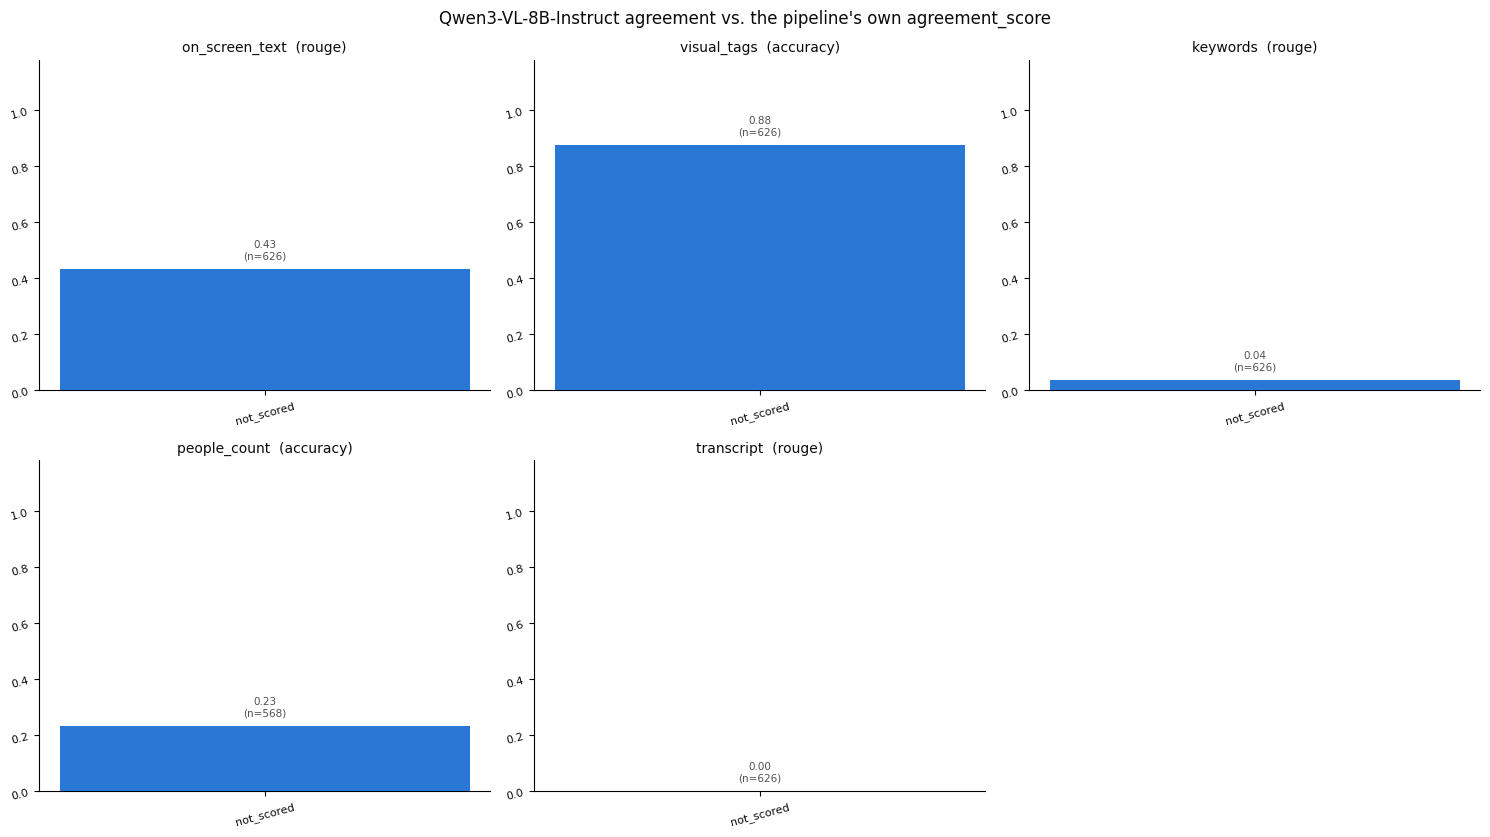

In [17]:
import matplotlib.pyplot as plt

_TIER_ORDER = ("not_scored", "low_agreement", "moderate_agreement", "high_agreement")
_INK, _INK_SOFT = "#0b0b0b", "#52514e"

for model_cfg in MODEL_CONFIGS:
    model_name = model_cfg["name"]
    model_report = QWEN_ACCURACY_REPORT[QWEN_ACCURACY_REPORT["model"] == model_name]
    if model_report.empty:
        print(f"Skipping chart for {model_name}: no scored rows (load failure or fully empty).")
        continue

    # 2x3 grid: one subplot per field (5 fields now that transcript is
    # included), with the 6th slot left unused and hidden below.
    figure, axes = plt.subplots(2, 3, figsize=(15, 8.5), facecolor="white")
    for axis, field in zip(axes.flat, SCORED_FIELDS):
        metric = FIELD_METRIC[field]
        subset = model_report[(model_report["field"] == field) & (model_report["metric"] == metric)]
        tiers = [t for t in _TIER_ORDER if t in set(subset["ground_truth_agreement_tier"])]
        means = [subset.loc[subset["ground_truth_agreement_tier"] == t, "value"].mean() for t in tiers]
        counts = [int((subset["ground_truth_agreement_tier"] == t).sum()) for t in tiers]

        bars = axis.bar(tiers, means, width=0.55, color="#2a78d6", zorder=3)
        for bar, count in zip(bars, counts):
            axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                       f"{bar.get_height():.2f}\n(n={count})", ha="center", va="bottom",
                       fontsize=7.5, color=_INK_SOFT)

        axis.set_ylim(0.0, 1.18)
        axis.set_facecolor("white")
        axis.set_title(f"{field}  ({metric})", color=_INK, fontsize=10)
        axis.tick_params(colors=_INK, labelrotation=15, labelsize=8)
        for spine in ("top", "right"):
            axis.spines[spine].set_visible(False)

    for unused_axis in axes.flat[len(SCORED_FIELDS):]:
        unused_axis.set_visible(False)

    figure.suptitle(f"{model_name} agreement vs. the pipeline's own agreement_score", color=_INK, fontsize=12)
    plt.tight_layout()

    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_name)
    plot_file = CFG.qwen_output_dir / f"{safe_name}_vs_agreement_tier.png"
    plt.savefig(plot_file, dpi=150)
    print("Saved to:", plot_file)
    plt.show()


## 12. Qualitative spot-check

A handful of clips, ground truth alongside every model's prediction, for the write-up.

In [18]:
sample_ids = QWEN_ACCURACY_REPORT["clip_id"].drop_duplicates().sample(
    min(5, QWEN_ACCURACY_REPORT["clip_id"].nunique()), random_state=SEED,
)

for clip_id in sample_ids:
    clip_row = CLIP_MANIFEST.loc[CLIP_MANIFEST["clip_id"] == clip_id].iloc[0]
    print(f"\n=== {clip_id} ({clip_row['split']}) ===")
    for field in SCORED_FIELDS:
        reference = ground_truth_value(clip_row.ground_truth_metadata, field)
        print(f"  {field}")
        print(f"    ground_truth: {reference!r}")
        for model_cfg in MODEL_CONFIGS:
            model_name = model_cfg["name"]
            record = ALL_QWEN_RECORDS.get(model_name, {}).get(clip_id, {})
            if record.get("status") != "ok":
                print(f"    {model_name:24s}: (not available -- {record.get('status', 'missing')})")
                continue
            prediction = record["metadata"]
            predicted = {
                "on_screen_text": prediction["on_screen_text"],
                "visual_tags": prediction["visual_tags"],
                "keywords": prediction["keywords"],
                "people_count": prediction["people_count_numeric"],
                "transcript": prediction["transcript_guess"],
            }[field]
            print(f"    {model_name:24s}: {predicted!r}")



=== 11_Poor_Mental_Health_on_Peace_Lines_150416_20818e1d__030000ms__clip0003 () ===
  on_screen_text
    ground_truth: []
    InternVL3-2B            : ['NVTV', 'BELFAST LOCAL TELEVISION']
    InternVL3-8B            : ['NVTW BELFAST LOCAL TELEVISION']
    Qwen3-VL-2B-Instruct    : ['NVTV', 'BELFAST LOCAL TELEVISION']
    Qwen3-VL-2B-Thinking    : ['NVTV', 'BELFAST LOCAL TELEVISION']
    Qwen3-VL-4B-Instruct    : ['NVTV', 'BELFAST LOCAL TELEVISION']
    Qwen3-VL-4B-Thinking    : ['NVTV', 'BELFAST LOCAL TELEVISION']
    Qwen3-VL-8B-Instruct    : ['NVTY', 'BELFAST LOCAL TELEVISION']
  visual_tags
    ground_truth: ['interview', 'person speaking', 'emergency services']
    InternVL3-2B            : ['interview', 'podium']
    InternVL3-8B            : ['news studio', 'interview']
    Qwen3-VL-2B-Instruct    : ['news studio', 'interview', 'person speaking', 'city street', 'building exterior']
    Qwen3-VL-2B-Thinking    : ['news studio', 'interview']
    Qwen3-VL-4B-Instruct    : ['news s

## 13. Download all results

Zips every results file this notebook produced -- the combined and per-model accuracy reports, the coverage table and the comparison table -- into a single archive, so every model's results can be compared side by side outside the notebook. In Colab this downloads the archive directly; on Kelvin2/JupyterLab there is no Colab-style browser download, so the archive's path is printed instead -- right-click it in the JupyterLab file browser and choose Download, or pull it to your own machine with `scp`/`rsync`.

In [20]:
import zipfile
from datetime import datetime
from pathlib import Path


OUTPUT_DIR = Path(CFG.qwen_output_dir)
ALLOWED_EXTENSIONS = {".json", ".csv"}

if not OUTPUT_DIR.is_dir():
    raise FileNotFoundError(
        f"Results folder not found: {OUTPUT_DIR}"
    )


# Find every JSON and CSV result file automatically.
RESULTS_FILES = sorted(
    path
    for path in OUTPUT_DIR.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() in ALLOWED_EXTENSIONS
        and ".partial" not in path.name.lower()
    )
)


if not RESULTS_FILES:
    raise FileNotFoundError(
        f"No JSON or CSV result files found in {OUTPUT_DIR}"
    )


run_tag = globals().get(
    "RUN_TAG",
    datetime.now().strftime("%Y%m%d_%H%M%S"),
)

# Create the ZIP in Colab's local storage.
RESULTS_ZIP_FILE = (
    Path("/content")
    / f"qwen_vl_JSON_CSV_results_{run_tag}.zip"
)


with zipfile.ZipFile(
    RESULTS_ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    allowZip64=True,
) as archive:

    for path in RESULTS_FILES:
        relative_path = path.relative_to(OUTPUT_DIR)

        try:
            archive.write(
                path,
                arcname=str(relative_path),
            )
        except (OSError, PermissionError) as error:
            print(
                f"Skipped {relative_path}: {error}"
            )


zip_size_mb = (
    RESULTS_ZIP_FILE.stat().st_size
    / (1024 * 1024)
)


print(
    f"Zipped {len(RESULTS_FILES)} "
    "JSON/CSV result files."
)
print("ZIP file:", RESULTS_ZIP_FILE)
print(f"ZIP size: {zip_size_mb:.2f} MB")

for path in RESULTS_FILES:
    print("  -", path.relative_to(OUTPUT_DIR))


try:
    from google.colab import files as colab_files

    print("\nStarting download...")
    colab_files.download(str(RESULTS_ZIP_FILE))

except ImportError:
    print(
        "\nNot running in Google Colab. "
        f"Download this file manually: {RESULTS_ZIP_FILE}"
    )

Zipped 44 JSON/CSV result files.
ZIP file: /content/qwen_vl_JSON_CSV_results_InternVL3-2B_InternVL3-8B_Qwen3-VL-2B-Instruct_Qwen3-VL-2B-Thinking_Qwen3-VL-4B-Instruct_Qwen3-VL-4B-Thinking_Qwen3-VL-8B-Instruct.zip
ZIP size: 10.32 MB
  - InternVL3-2B_remaining_clips.csv
  - InternVL3-8B_remaining_clips.csv
  - Qwen3-VL-2B-Instruct_remaining_clips.csv
  - Qwen3-VL-2B-Thinking_remaining_clips.csv
  - Qwen3-VL-4B-Instruct_remaining_clips.csv
  - Qwen3-VL-4B-Thinking_remaining_clips.csv
  - Qwen3-VL-8B-Instruct_remaining_clips.csv
  - all_models_completion_status.csv
  - all_models_remaining_clips.csv
  - colab_pending_plan_Qwen3-VL-2B-Thinking.json
  - colab_pending_plan_Qwen3-VL-4B-Thinking.json
  - predictions_InternVL3-2B.json
  - predictions_InternVL3-8B.json
  - predictions_Qwen3-VL-2B-Instruct.json
  - predictions_Qwen3-VL-2B-Thinking.json
  - predictions_Qwen3-VL-4B-Instruct.json
  - predictions_Qwen3-VL-4B-Thinking.backup_before_repair_20260911T205248Z.json
  - predictions_Qwen3-VL-4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Limitations

- **No audio modality -- `transcript` is scored anyway, deliberately.**
  None of these models take audio input, so `transcript_guess` is
  necessarily a visual-only speculation (lip movement, body language,
  on-screen text, setting), not real transcription -- the models were
  never given the information needed to succeed at this task in the way
  they can for the other four fields. It's included specifically to
  measure and report *how much* speech content is unrecoverable from
  vision alone, as a quantified finding in its own right -- low or
  near-zero `transcript` scores should be read as expected evidence of
  that gap, not as the models performing badly at something they could
  reasonably have been expected to do. Prompted explicitly to return an
  empty string when it has no reasonable basis to guess (rather than
  invent dialogue), a model that does so against a non-empty ground-truth
  transcript still scores 0.0 -- an honest empty guess is not rewarded
  over a lucky invented one by this scoring, which is itself worth noting
  when interpreting the numbers. Separately, the `keywords` comparison is
  not perfectly like-for-like: the ground truth's keywords are derived
  from the *transcript* (KeyBERT/YAKE/TF-IDF), while each model's keywords
  are derived only from what it can see in the frames.
- **Model scope.** `Qwen3-VL-{2B,4B}-{Instruct,Thinking}` run at full
  bf16/fp16 precision; `Qwen3-VL-8B-Instruct` runs int4-quantized via
  bitsandbytes (see the intro cell) because it does not fit comfortably in
  this 20GB MIG slice's memory budget otherwise. 32B variants, all
  `-FP8` checkpoints, and all `-GGUF` checkpoints are excluded entirely for
  the hardware/tooling reasons given in the intro cell, not because they
  were tested and dropped.
- **8B quantization is a real methodological caveat, not just a technical
  detail.** int4 quantization measurably changes model outputs relative to
  the bf16/fp16 the other four models run at full precision -- 8B's scores
  are not directly comparable to the others on equal footing, and this
  should be stated explicitly wherever these results are reported, not
  just noted here.
- **Same prompt and frame budget (4 frames) for every model,** including
  both Instruct and Thinking variants -- this notebook deliberately holds
  the protocol constant across models rather than tuning per model, to
  keep the comparison fair rather than optimal for any one of them. Note
  that 4 frames (not 6) is used here specifically because 6 frames caused
  `Qwen3-VL-8B-Instruct` to run out of memory during prefill on this 20GB
  MIG slice; this is a disclosed hardware-driven deviation from the frame
  budget used in the Colab-based notebooks and the main pipeline, not a
  methodological choice, and should be reported as such. Thinking models
  do get a larger token budget (1400 vs. 700) than Instruct models, since
  that budget has to cover their reasoning trace as well as the final
  JSON answer, not just the answer itself.
- **`-Thinking` JSON extraction is a heuristic.** `extract_last_json_object`
  assumes the model's *final* answer is the last balanced JSON block in its
  output. If a Thinking model's reasoning trace happens to end with a
  well-formed but irrelevant JSON-shaped example, this would be picked up
  incorrectly. Failures of this kind would show up as unusually low scores
  for a Thinking model relative to its Instruct sibling -- worth checking
  the raw `qwen2b_predictions`-style JSON files (now per model, e.g.
  `predictions_Qwen3-VL-2B-Thinking.json`) if that pattern appears.
- **`-Thinking` forced-conclusion fallback is a deviation from pure
  single-pass generation, and only Instruct models don't get it.**
  `force_json_continuation` gives `-Thinking` models a second chance (one
  extra, short, forced generation call) that `-Instruct` models never
  receive, specifically when the first pass exhausts its budget without
  producing JSON -- e.g. on clips with an ambiguous crowd size or unclear
  on-screen text that the model deliberates over at length instead of
  concluding. This recovers otherwise-missing data rather than changing
  any answer that was already successfully produced, but it is still an
  asymmetry between how Instruct and Thinking models are evaluated, and
  should be reported as such rather than presented as identical protocols.
  A clip whose successful prediction came from this fallback is not
  separately flagged in the predictions JSON beyond the `raw_response`
  text itself containing the forced-continuation marker text
  (`"I will stop analyzing now..."`), which can be grepped for if that
  distinction matters for reporting.
- **Sequential loading, not simultaneous.** Models are loaded and evaluated
  one at a time and fully unloaded before the next, to keep this within
  the 20GB MIG slice's memory budget -- this notebook does not reflect
  performance under concurrent multi-model serving.
- **Uniform frame sampling**, not the main pipeline's scene-aware sampler,
  for the same reasons given in the main pipeline notebook's own version of
  this note: keeps this evaluation self-contained and simple to reproduce.
- **Zero-shot, single run, greedy decoding** (`do_sample=False`) for every
  model; no variance estimate across repeated samples or prompt phrasings
  is reported.
- **Controlled vocabulary for `visual_tags`.** Every model was constrained
  to the same fixed label set the pipeline's own CLIP tagger uses, which
  makes the multi-label accuracy comparison meaningful but also caps what
  a model can express.
- **ROUGE recall, not F-measure.** `on_screen_text`, `keywords`, and
  `transcript` are scored on how much of the ground truth's content each
  model's output recovers (recall), not on how much of that output is
  "extra" (precision) or a balance of both (F-measure/F1). The raw
  `qwen_value` / `ground_truth_value` columns in the CSV are there to
  sanity-check this by eye.
- **Multi-label accuracy on `visual_tags` rewards "mostly absent" tag
  sets.** With 34 possible labels and at most 5 selected, predicting
  nothing at all already scores high on Hamming accuracy. Read this number
  alongside the qualitative spot-check in Section 12, not in isolation.
- **JSON parse failures counted as pipeline failures**, not wrong answers:
  clips where a model's output could not be parsed as JSON are recorded
  with `status: "error"` and excluded from the accuracy report rather than
  scored as zero -- the coverage table in Section 10 shows how many clips
  each model was actually scored on.
- **Reference standard is the pipeline's own automatic consensus**, not
  independent human ground truth -- this measures agreement between
  automatic systems, not real-world correctness. Section 18B of the main
  notebook is the relevant comparison against human labels, if that
  stronger claim is needed elsewhere in the dissertation.
